In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sys.path.append(os.path.abspath('..'))
from src.data_loader import DataLoader

# Model Directory
MODEL_DIR = "../models/trained_models/"
print(f"Loading models from: {MODEL_DIR}")

# Load Artifacts
try:
    xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgboost_final.pkl"))
    lin_model = joblib.load(os.path.join(MODEL_DIR, "linear_regression.pkl"))
    scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
    print(" System Ready. Models Loaded.")
except FileNotFoundError:
    print(" Error: Models not found. Please run 'main.py' first.")

Loading models from: ../models/trained_models/
 System Ready. Models Loaded.


In [3]:
# Load Data
loader = DataLoader(raw_data_path="../data/raw/airfoil_self_noise.csv")
df = loader.load_raw_data()

X = df.drop(columns=['Sound_Pressure_Level'])
y_true = df['Sound_Pressure_Level']

# Scale Data (Using the scaler fitted during training)
X_scaled = scaler.transform(X)

# Generate Predictions
pred_lin = lin_model.predict(X_scaled)
pred_xgb = xgb_model.predict(X_scaled)

# Create Results DataFrame
res = pd.DataFrame({
    'Actual': y_true,
    'Linear': pred_lin,
    'XGBoost': pred_xgb
})
res['Err_Lin'] = res['Actual'] - res['Linear']
res['Err_XGB'] = res['Actual'] - res['XGBoost']

res.head()

[INFO] Raw data loaded successfully. Shape: (1503, 6)


,Actual,Linear,XGBoost,Err_Lin,Err_XGB
0,126.201,127.625412,126.166046,-1.424412,0.034954
1,125.201,127.371072,125.462860,-2.170072,-0.261860
2,125.951,127.053146,125.799507,-1.102146,0.151493
3,127.591,126.608050,127.489845,0.982950,0.101155
4,127.461,126.099368,127.422752,1.361632,0.038248


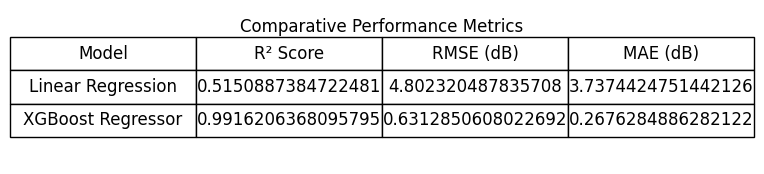

In [4]:
metrics = {
    'Model': ['Linear Regression', 'XGBoost Regressor'],
    'R² Score': [r2_score(y_true, pred_lin), r2_score(y_true, pred_xgb)],
    'RMSE (dB)': [np.sqrt(mean_squared_error(y_true, pred_lin)), np.sqrt(mean_squared_error(y_true, pred_xgb))],
    'MAE (dB)': [mean_absolute_error(y_true, pred_lin), mean_absolute_error(y_true, pred_xgb)]
}

metrics_df = pd.DataFrame(metrics)

# Visualize Table
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
plt.title("Comparative Performance Metrics", y=0.8)
plt.show()

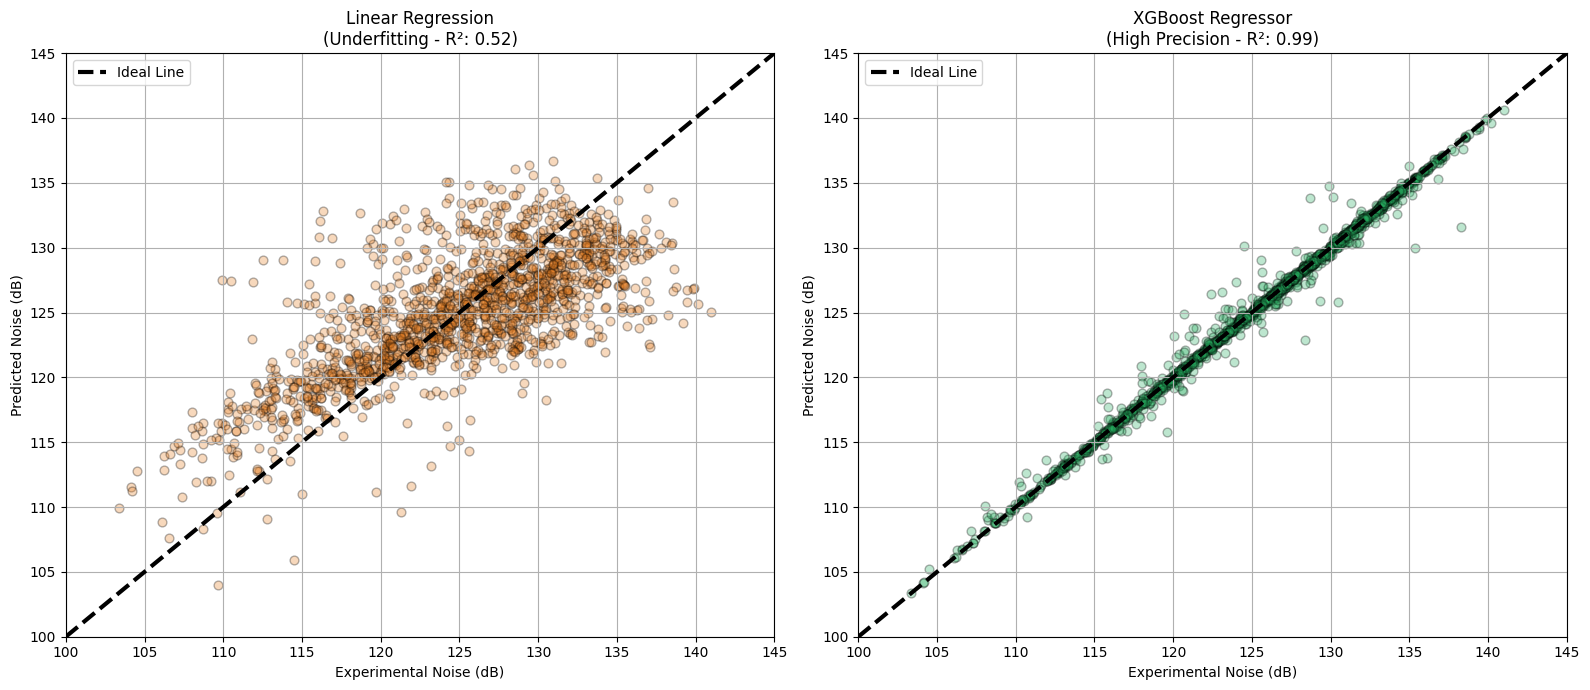

In [5]:
plt.figure(figsize=(16, 7))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(res['Actual'], res['Linear'], alpha=0.3, color='#E67E22', edgecolor='k', s=40)
plt.plot([100, 145], [100, 145], 'k--', lw=3, label='Ideal Line')
plt.title(f"Linear Regression\n(Underfitting - R²: {metrics_df.iloc[0,1]:.2f})")
plt.xlabel("Experimental Noise (dB)")
plt.ylabel("Predicted Noise (dB)")
plt.xlim(100, 145); plt.ylim(100, 145)
plt.grid(True)
plt.legend()

# XGBoost Plot
plt.subplot(1, 2, 2)
plt.scatter(res['Actual'], res['XGBoost'], alpha=0.3, color='#27AE60', edgecolor='k', s=40)
plt.plot([100, 145], [100, 145], 'k--', lw=3, label='Ideal Line')
plt.title(f"XGBoost Regressor\n(High Precision - R²: {metrics_df.iloc[1,1]:.2f})")
plt.xlabel("Experimental Noise (dB)")
plt.ylabel("Predicted Noise (dB)")
plt.xlim(100, 145); plt.ylim(100, 145)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/98/t973kl4s23l931r_t6tztnsc0000gn/T/ipykernel_46142/3967926518.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='magma')


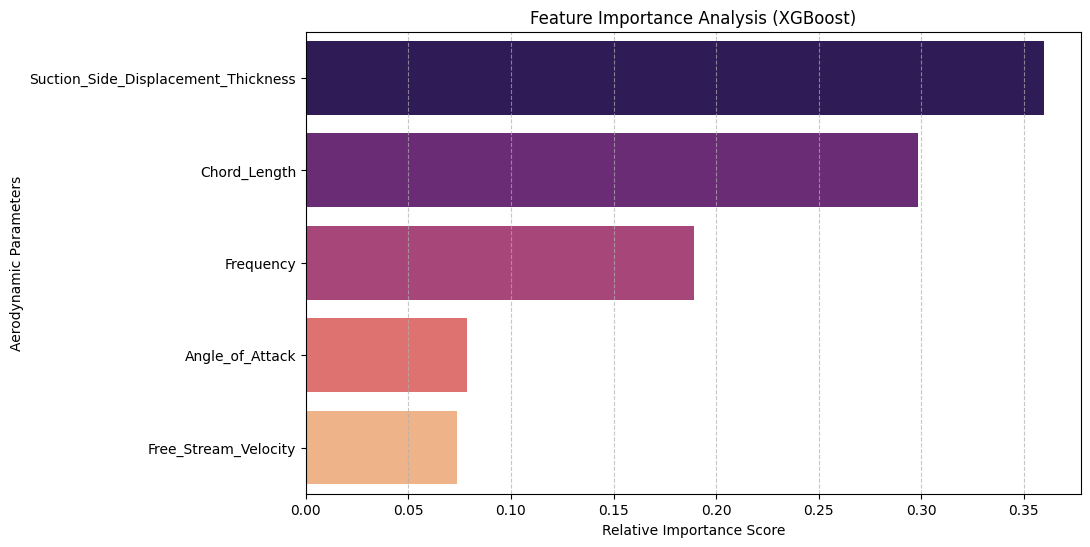


📝 **Paper Discussion:** - According to the model, 'Frequency' is the most dominant factor determining noise levels.
- This is followed by 'Chord Length' and 'Suction Side Displacement Thickness'.
- These findings align well with aeroacoustic theory regarding spectral dominance.



In [6]:
# Extract feature importance scores from XGBoost
importances = xgb_model.feature_importances_
feature_names = X.columns

# Create DataFrame and sort
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='magma')
plt.title("Feature Importance Analysis (XGBoost)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Aerodynamic Parameters")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("""
📝 **Paper Discussion:** - According to the model, 'Frequency' is the most dominant factor determining noise levels.
- This is followed by 'Chord Length' and 'Suction Side Displacement Thickness'.
- These findings align well with aeroacoustic theory regarding spectral dominance.
""")

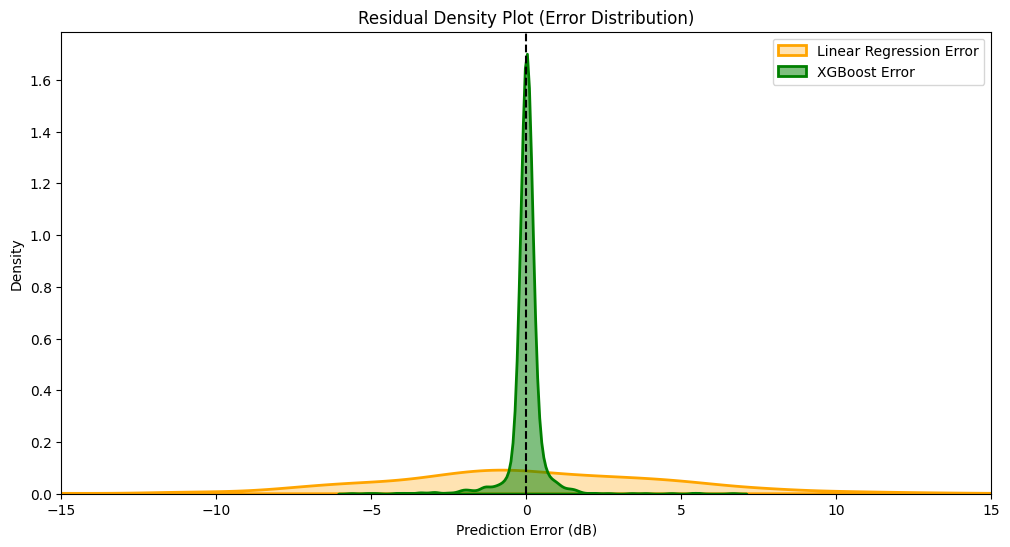

As observed, the XGBoost error distribution forms a very sharp peak around 0 (indicating low error), whereas the Linear model exhibits a much larger variance.


In [7]:
# Distribution of errors (Linear errors are wide, XGBoost errors should be peaked near 0)
plt.figure(figsize=(12, 6))

sns.kdeplot(res['Err_Lin'], fill=True, color='orange', label='Linear Regression Error', alpha=0.3, linewidth=2)
sns.kdeplot(res['Err_XGB'], fill=True, color='green', label='XGBoost Error', alpha=0.5, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Density Plot (Error Distribution)")
plt.xlabel("Prediction Error (dB)")
plt.ylabel("Density")
plt.legend()
plt.xlim(-15, 15) # Focus on the main error region
plt.show()

print("As observed, the XGBoost error distribution forms a very sharp peak around 0 (indicating low error), whereas the Linear model exhibits a much larger variance.")